In [1]:
import pandas as pd
import os.path as op
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

bids_folder = '/Users/mrenke/data/ds-stressrisk'
plot_folder_path = '/Users/mrenke/Desktop/StressRisk/figures/plots/poster'

sns.set_context('talk')
sns.set_theme('paper', 'white', font='helvetica', font_scale=2, palette='tab10')


# Methdos

## RNP & psychometric curve illustration

In [2]:
from stress_risk.behavior.utils import get_data
df = get_data()
group_mapping = df.groupby(['subject', 'group']).size().reset_index(['group']).drop(0, axis=1)


ModuleNotFoundError: No module named 'bauer'

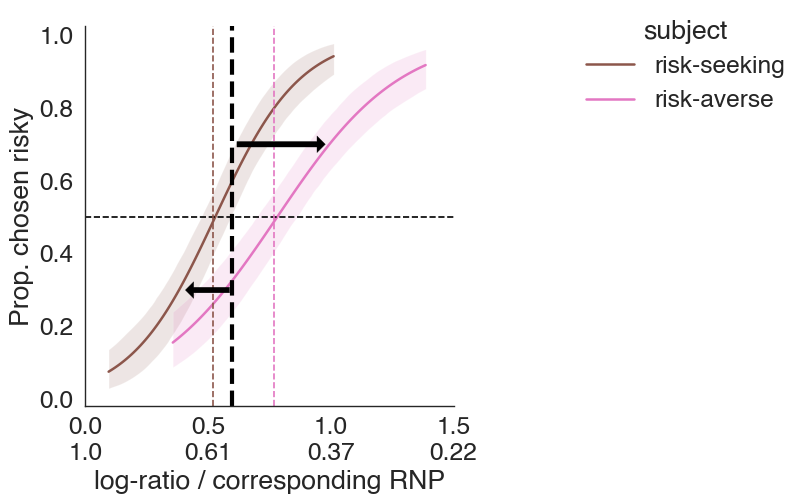

In [17]:
sns.set_theme('paper', 'white', font='helvetica', font_scale=2, palette='tab10')

d = df.loc[([1,4])] # subject = 1

fac = sns.lmplot(d.reset_index(), x = 'log(risky/safe)', y = 'chose_risky', hue= 'subject',  logistic= True,palette=sns.color_palette()[5:], scatter=False ) # col = 'subject', , legend_out=True

plt.axhline(.5, c='k', ls='--')
plt.axvline(np.log(1/0.55), c='k', ls='--', linewidth = 3)

xlbls1 = np.round(fac.ax.get_xticks(),2)
xlbls2 = np.round(np.exp(xlbls1),2)
xlbls3 = [np.round(1/item,2) for item in xlbls2]
xlbls = [str(a) + '\n' + str(c) for a, c in zip(xlbls1, xlbls3)]
fac.set_xticklabels(xlbls)

plt.axvline(.52, c=sns.color_palette()[5], ls='--')
plt.axvline(.77, c=sns.color_palette()[6], ls='--')

plt.ylabel('Prop. chosen risky')
plt.xlabel('log-ratio / corresponding RNP')

legend_labels = {"1": "risk-seeking", "4": "risk-averse"}
for t, l in zip(fac._legend.texts, legend_labels.values()):
    t.set_text(l)
sns.move_legend(fac, "upper left",bbox_to_anchor=(1,1))

y_arrow = 0.3
plt.annotate('', xytext=(np.log(1/0.55),y_arrow), xy=(np.log(1/0.55)-0.2,y_arrow), arrowprops={"color":'k', "linewidth":.2, 'shrink':0.05, 'headlength':6})
y_arrow = 0.7
plt.annotate('', xytext=(np.log(1/0.55),y_arrow), xy=(np.log(1/0.55)+ 0.4,y_arrow), arrowprops={"color":'k', "linewidth":.2, 'shrink':0.05, 'headlength':6})

plt.title('')
plt.savefig(op.join(plot_folder_path, f'psychometric-curve_rnp_illustration_02.pdf'), transparent=True)


## NLC model illustration

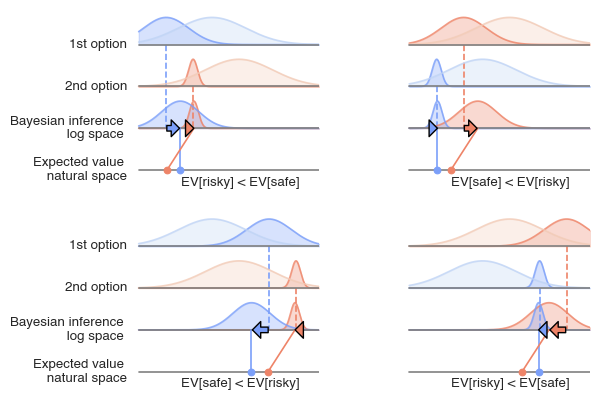

In [5]:

from utils import plot_bayesian_inference, annotat_bayesian_inference
import seaborn as sns 
import matplotlib.pyplot as plt

sns.set_theme('paper', 'white', font='helvetica', font_scale=1, palette='tab10')

plt.subplot(221)
plot_bayesian_inference(risky_first = False,base = 5)
annotat_bayesian_inference()
plt.subplot(222)
plot_bayesian_inference(risky_first = True,base = 5)
plt.subplot(223)
plot_bayesian_inference(risky_first = False,base = 49)
annotat_bayesian_inference()
plt.subplot(224)
plot_bayesian_inference(risky_first = True,base = 49)

plt.savefig(op.join(plot_folder_path, f'NLC-model_illustration_01.pdf'), bbox_inches='tight')


# Results

### probit model

In [ ]:
params = pd.read_csv('/Users/mrenke/data/ds-stressrisk/interim_sum_data/probit-1_pposterior_params.csv')
#params.columns = params.columns.droplevel(params.columns[0])
params = params.drop('Unnamed: 0',axis=1)
params = params.set_index(['param','subject','session','group','risky_first','n_safe'])

params.head()

## just created plots in fi2_rnp 

### NLC model

In [3]:
import arviz as az
from bauer.utils.math import softplus_np

idata = az.from_netcdf(op.join(bids_folder, 'derivatives', 'cogmodels', f'model-1_trace.netcdf'))

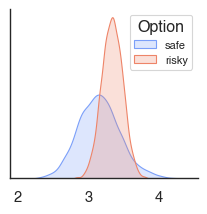

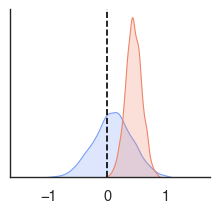

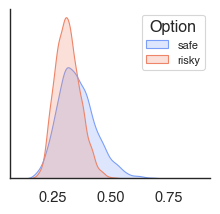

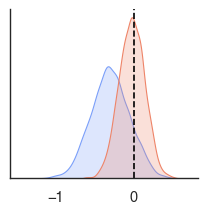

In [8]:
#plt.title('prior')
sns.set_theme('paper', 'white', font='helvetica', font_scale=1.2, palette='tab10')

palette = sns.color_palette('coolwarm', 4)
palette = [palette[ix] for ix in [0, 3]]

for param in ['mu', 'std']:
    for regressor in ['Intercept' , 'session:group']:
        
        if param == 'std' and regressor == 'Intercept':
            val = 'value_softpl'
        else:
            val = 'value'
        prior_mus= pd.concat((idata.posterior[f'safe_prior_{param}_mu'].to_dataframe(), (idata.posterior[f'risky_prior_{param}_mu'].to_dataframe())), axis=1)
        prior_mus.columns.name = 'parameter'
        prior_mus.index = prior_mus.index.set_names(['chain','draw','regressor']) 
        prior_mus = prior_mus.stack().to_frame('value')
        prior_mus['Option'] = prior_mus.index.get_level_values('parameter').map({f'safe_prior_{param}_mu':'safe', f'risky_prior_{param}_mu':'risky'})
        prior_mus['value_softpl'] = softplus_np(prior_mus['value']) # for param == 'std' and regressor == 'Intercept'

        fac = sns.FacetGrid(prior_mus.xs(regressor, 0,'regressor').reset_index(), hue='Option', palette=palette, aspect=1.1, height=2.5)
        fac.map(sns.kdeplot, val, fill=True)
        fac.set(xlabel=None, ylabel=None, yticks=[])

        if regressor =='Intercept': 
            plt.legend(title='Option',loc='upper right',fontsize='x-small')
        #plt.title(f'{param}_{regressor}')
        
        if regressor =='session:group': 
            plt.axvline(0, c='black', ls='--')

        plt.savefig(op.join(plot_folder_path, f'NLC_model-1_prior_{param}_{regressor}.pdf'), bbox_inches='tight')


In [9]:
evidence_sd = pd.concat((idata.posterior['n1_evidence_sd_mu'].to_dataframe(), (idata.posterior['n2_evidence_sd_mu'].to_dataframe())), axis=1)
evidence_sd.columns.name = 'parameter'
evidence_sd.index = evidence_sd.index.set_names(['chain','draw','regressor']) # get handel on regressors #'subject',
evidence_sd = evidence_sd.stack().to_frame('value')
evidence_sd['Noise'] = evidence_sd.index.get_level_values('parameter').map({'n1_evidence_sd_mu':'1', 'n2_evidence_sd_mu':'2'})
evidence_sd['value_softpl'] = softplus_np(evidence_sd['value'])


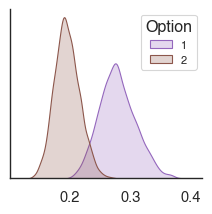

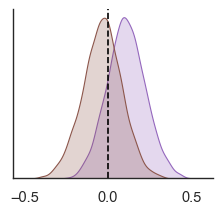

In [10]:
#plt.title('Evidence sd mu')
palette = sns.color_palette()[4:]
#palette = [palette[ix] for ix in [6,8]]

for regressor in ['Intercept' , 'session:group']:
    if regressor == 'Intercept':
        val = 'value_softpl'
    elif regressor =='session:group': 
        val = 'value'

    fac = sns.FacetGrid(evidence_sd.xs(regressor, 0,'regressor').reset_index(), hue='Noise', palette=palette, aspect=1.1, height=2.5)
    fac.map(sns.kdeplot, val, fill=True)
    fac.set(xlabel=None, ylabel=None, yticks=[])
    if regressor =='Intercept':
        plt.legend(title='Option',loc='upper right',fontsize='x-small')
    if regressor =='session:group': 
        plt.axvline(0, c='black', ls='--')

    #plt.xlim([0,0.5])
    plt.savefig(op.join(plot_folder_path, f'NLC_model-1_evidence_sd_{regressor}.pdf'), bbox_inches='tight')


## Decoding

In [3]:
# E_diff
sns.set_theme('paper', 'white', font='helvetica', font_scale=2, palette='tab10')


Es_within = pd.read_csv(op.join(bids_folder, 'interim_sum_data', 'within_ses_decodedE.csv'))
Es_across = pd.read_csv(op.join(bids_folder, 'interim_sum_data','across_ses_decodedE.csv'))

Es_within = Es_within.set_index(['subject', 'trial_nr', 'session']).rename(mapper={'E':'E_w', 'sd':'sd_w'}, axis=1).xs(2,0,'session')
Es_across = Es_across.set_index(['subject', 'trial_nr']).rename(mapper={'E':'E_a', 'sd':'sd_a'}, axis=1)

from stress_risk.utils.data import add_cond2df
Es = Es_within.join(Es_across).set_index('risky_first', append=True)
Es = add_cond2df(Es)
Es['E_dif'] = Es['E_a'] - Es['E_w']

/Users/mrenke/mambaforge/envs/numrefields/lib/python3.10/site-packages/nilearn/glm/__init__.py:55: FutureWarning: The nilearn.glm module is experimental. It may change in any future release of Nilearn.
  warn('The nilearn.glm module is experimental. '
/Users/mrenke/mambaforge/envs/numrefields/lib/python3.10/site-packages/tqdm/auto.py:22: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


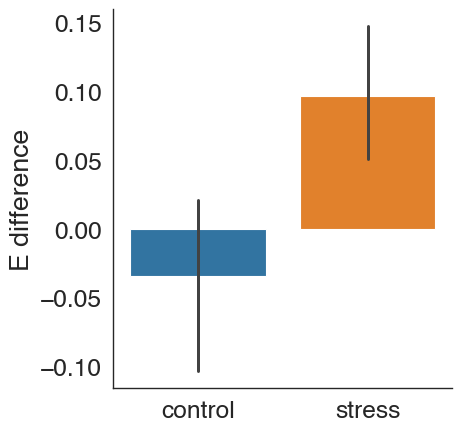

In [103]:


temp = Es.groupby(['subject']).mean()
temp['group_name'] = np.where(temp['group'] == 0, 'control', 'stress')

sns.catplot(data=temp.reset_index(), x='group_name', y='E_dif',  kind='bar') #kind='bar',,errorbar=get_hdi
plt.xlabel(None)
plt.ylabel('E difference')
plt.savefig(op.join(plot_folder_path, 'E_diff_catplot-groups.pdf'), bbox_inches='tight')

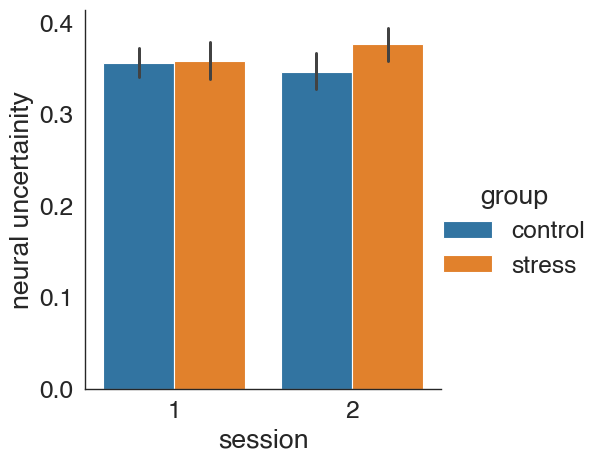

In [100]:
df_wdec = pd.read_csv(op.join(bids_folder, 'interim_sum_data','within-ses-decod_r-sds.csv'))
df_wdec = df_wdec.set_index(['group','subject','session'])

sns.catplot(data=df_wdec.reset_index(), x='session', y='sds',  kind='bar', hue='group',errorbar=('ci', 95)) #kind='bar',,errorbar=get_hdi
plt.ylabel('neural uncertainity')
plt.savefig(op.join(plot_folder_path, 'neural-uncertainty_catplot-groups.pdf'), bbox_inches='tight')

Text(108.88707083333337, 0.5, 'neural uncertainity')

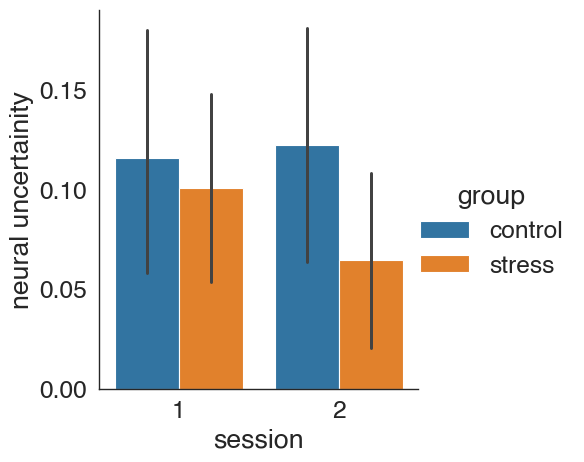

In [97]:
sns.catplot(data=df_wdec.reset_index(), x='session', y='r',  kind='bar', hue='group') #kind='bar',,errorbar=get_hdi
plt.ylabel('neural uncertainity')

## AUC group difference

In [65]:
from stress_risk.analyse_results.utils import get_stress_level
df_stress_sr = pd.read_csv('/Users/mrenke/data/ds-stressrisk/addMeasures/selfRated_Stress.csv')

df_auc = get_stress_level()
df_comb = df_auc.join(group_mapping).join(df_stress_sr.set_index(['subject','group']))
df_comb['group'] = np.where( df_comb['group']== 0.0, 'control', 'stress')


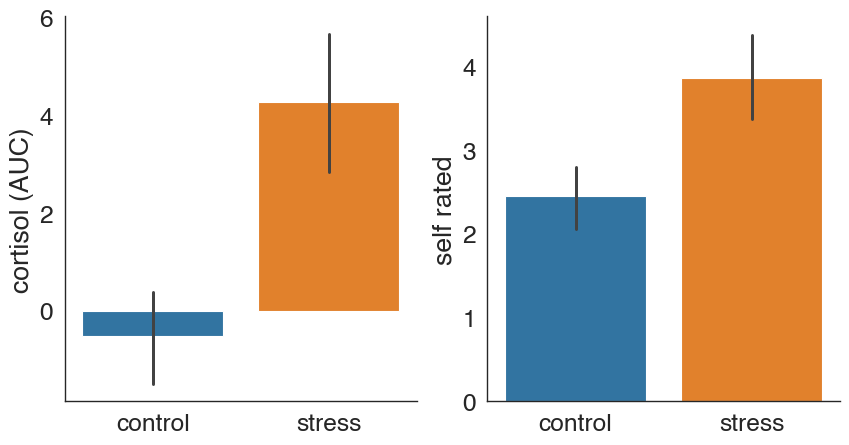

In [70]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10,5))

sns.barplot(ax=ax1,data=df_comb, y='AUC',x='group')
ax1.set(xlabel=None, ylabel='cortisol (AUC)') 
sns.barplot(ax=ax2,data=df_comb, y='mean_stress',x='group')
ax2.set(xlabel=None, ylabel='self rated')
sns.despine()

plt.savefig(op.join(plot_folder_path, 'stress.pdf'), bbox_inches='tight')

## behav - neural - corr.

In [86]:
len(Es.index.unique('subject')) # sub 1 is missing

49

In [4]:
df_prior_shift = pd.read_csv('/Users/mrenke/data/ds-stressrisk/interim_sum_data/subwise_change_risky_prior_model-1.csv')
df_es = Es.groupby(['subject'])['E_dif'].mean().to_frame()

df_comb = df_prior_shift.join(df_es)
df_comb.head()

,subject,risky_prior_mu,E_dif
0,1,-0.059489,NaN
1,2,-0.037181,NaN
2,5,-0.057227,0.010657
3,9,-0.275947,0.075062
4,10,-0.171761,0.143165


Text(0.5, 1.0, ' \n r=0.25, p= 0.13236')

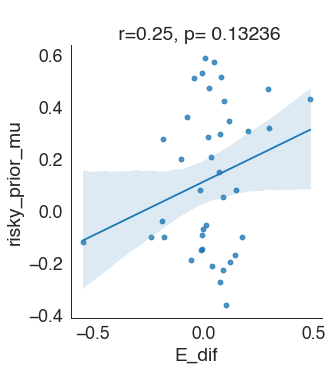

/Users/mrenke/mambaforge/envs/numrefields/lib/python3.10/site-packages/outdated/utils.py:14: OutdatedPackageWarning: The package outdated is out of date. Your version is 0.2.1, the latest is 0.2.2.
Set the environment variable OUTDATED_IGNORE=1 to disable these warnings.
  return warn(
/Users/mrenke/mambaforge/envs/numrefields/lib/python3.10/site-packages/outdated/utils.py:14: OutdatedPackageWarning: The package pingouin is out of date. Your version is 0.5.2, the latest is 0.5.3.
Set the environment variable OUTDATED_IGNORE=1 to disable these warnings.
  return warn(


In [5]:
import pingouin

name_prior = 'risky_prior'

sns.lmplot(data=df_comb.reset_index() , x='E_dif', y = f'{name_prior}_mu') #, hue='group'
cor = pingouin.corr(df_comb['E_dif'], df_comb[f'{name_prior}_mu'])
r_ = np.round(cor['r'][0], 2)
p = np.round(cor['p-val'][0], 5)
plt.title(f' \n r={r_}, p= {p}')